# **Actividad 5 - Detección de bordes de imagen**
### Sistemas de Visión
### José Antonio Martínez Calan
### 2127803

**Librerias**

In [10]:
import cv2
import os
import numpy as np
import matplotlib.pyplot as plt

**Función para procesar imagenes**

In [11]:
def procesar_imagen(nombre_archivo, aplicar_ruido=False):
    # Leer imagen en escala de grises
    img = cv2.imread(nombre_archivo, cv2.IMREAD_GRAYSCALE)

    if img is None:
        print(f"No se pudo cargar la imagen: {nombre_archivo}")
        return

    # Si se requiere, agregar ruido gaussiano para análisis
    if aplicar_ruido:
        ruido = np.random.normal(0, 15, img.shape)
        img = np.clip(img + ruido, 0, 255).astype(np.uint8)

    #1 Filtro Sobel
    sobel_x = cv2.Sobel(img, cv2.CV_64F, 1, 0, ksize=3)   # Bordes horizontales
    sobel_y = cv2.Sobel(img, cv2.CV_64F, 0, 1, ksize=3)   # Bordes verticales

    sobel_x = np.uint8(np.absolute(sobel_x))
    sobel_y = np.uint8(np.absolute(sobel_y))
    sobel_combinado = cv2.addWeighted(sobel_x, 0.5, sobel_y, 0.5, 0)

    # 2️ Filtro Laplaciano
    laplaciano = cv2.Laplacian(img, cv2.CV_64F)
    laplaciano = np.uint8(np.absolute(laplaciano))

    # 3️ Mostrar resultados
    plt.figure(figsize=(10, 8))
    plt.suptitle(f"Detección de Bordes - {nombre_archivo}{' (con ruido)' if aplicar_ruido else ''}",
                 fontsize=14, fontweight='bold')

    plt.subplot(2, 3, 1)
    plt.imshow(cv2.imread(nombre_archivo)[..., ::-1])
    plt.title("Original (color)")
    plt.axis("off")

    plt.subplot(2, 3, 2)
    plt.imshow(sobel_x, cmap='gray')
    plt.title("Sobel X (Horizontales)")
    plt.axis("off")

    plt.subplot(2, 3, 3)
    plt.imshow(sobel_y, cmap='gray')
    plt.title("Sobel Y (Verticales)")
    plt.axis("off")

    plt.subplot(2, 3, 4)
    plt.imshow(sobel_combinado, cmap='gray')
    plt.title("Sobel Combinado (X+Y)")
    plt.axis("off")

    plt.subplot(2, 3, 5)
    plt.imshow(laplaciano, cmap='gray')
    plt.title("Laplaciano (2ª derivada)")
    plt.axis("off")

    plt.subplot(2, 3, 6)
    plt.imshow(img, cmap='gray')
    plt.title("Escala de grises" if not aplicar_ruido else "Imagen con ruido")
    plt.axis("off")

    plt.tight_layout()
    plt.show()

    # 4 Guardar resultados
    etiqueta = "_ruido" if aplicar_ruido else ""
    base = nombre_archivo.split('.')[0]
    cv2.imwrite(f"resultado_sobelX_{base}{etiqueta}.jpg", sobel_x)
    cv2.imwrite(f"resultado_sobelY_{base}{etiqueta}.jpg", sobel_y)
    cv2.imwrite(f"resultado_sobelComb_{base}{etiqueta}.jpg", sobel_combinado)
    cv2.imwrite(f"resultado_laplaciano_{base}{etiqueta}.jpg", laplaciano)

    print(f"Procesamiento completado: {nombre_archivo}{' (con ruido)' if aplicar_ruido else ''}")

**Imágenes a procesar**

In [12]:
imagenes = ["Foto.jpeg", "ave1.jpg", "ave2.jpg", "ave3.jpg"]
print("Imágenes detectadas para procesar:")
for i, nombre in enumerate(imagenes, 1):
    print(f"{i}. {nombre}")


Imágenes detectadas para procesar:
1. Foto.jpeg
2. ave1.jpg
3. ave2.jpg
4. ave3.jpg


**Procesamiento sin ruido**


 Procesamiento SIN ruido:


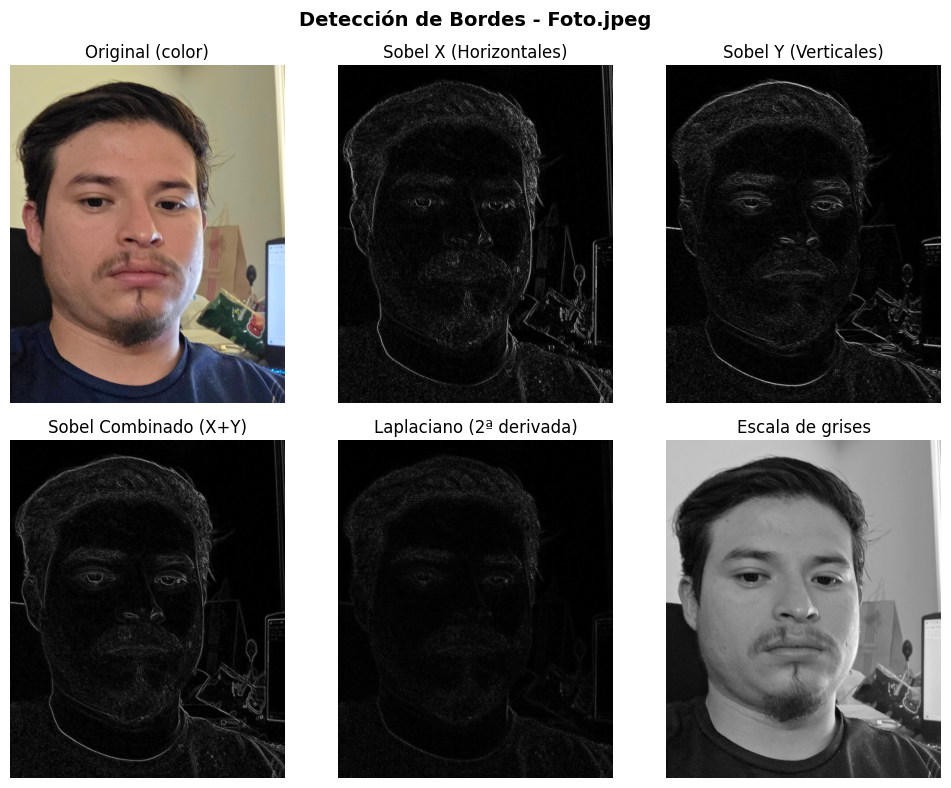

Procesamiento completado: Foto.jpeg


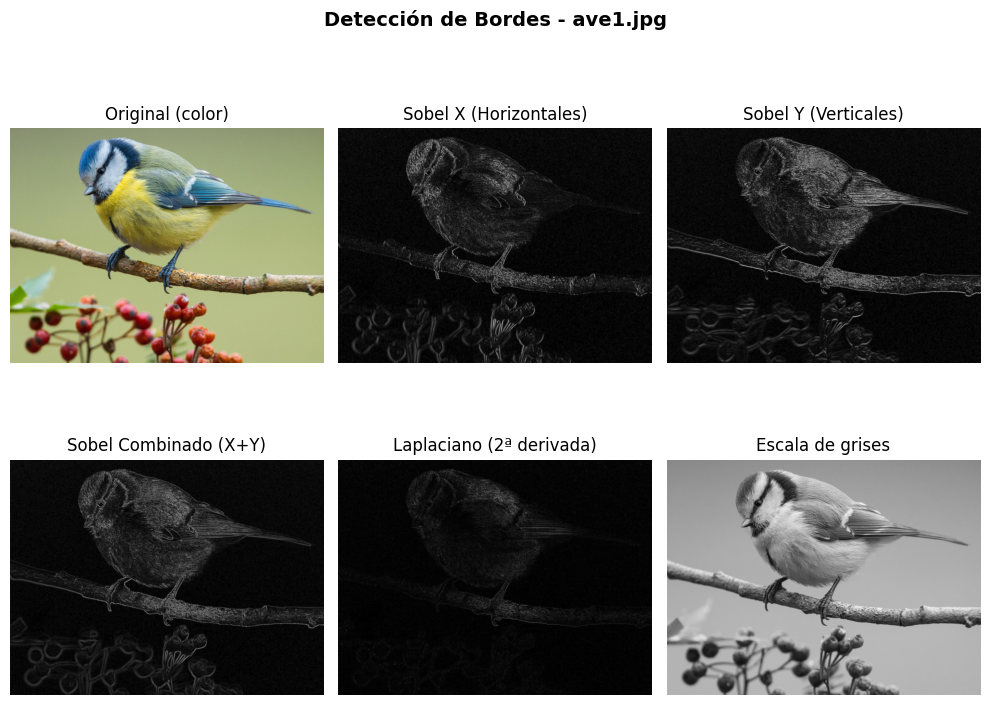

Procesamiento completado: ave1.jpg


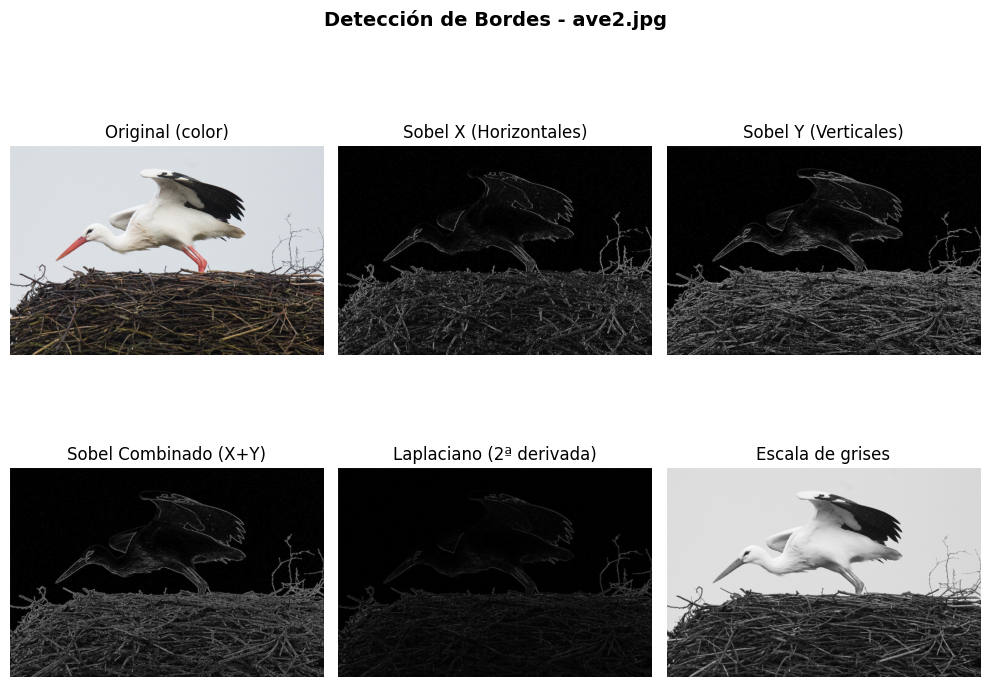

Procesamiento completado: ave2.jpg


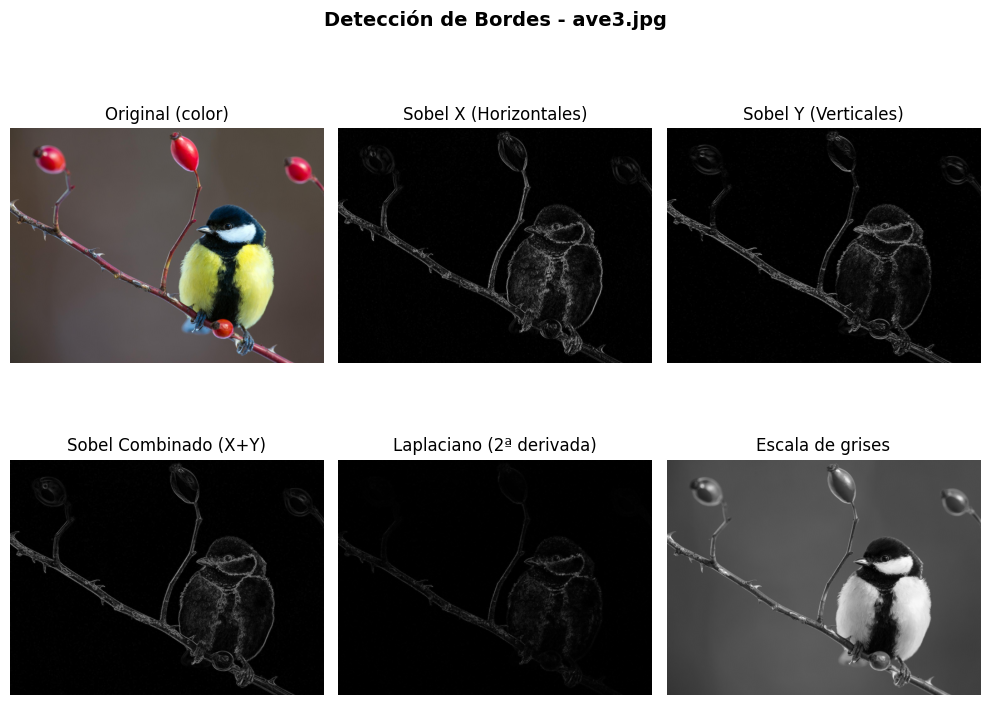

Procesamiento completado: ave3.jpg

 Procesamiento de imágenes sin ruido completado.


In [13]:
print("\n Procesamiento SIN ruido:")
for img in imagenes:
    procesar_imagen(img, aplicar_ruido=False)
print("\n Procesamiento de imágenes sin ruido completado.")


**Procesamiento con ruido o sensibilidad al ruido**


 Procesamiento CON ruido (para análisis de sensibilidad):


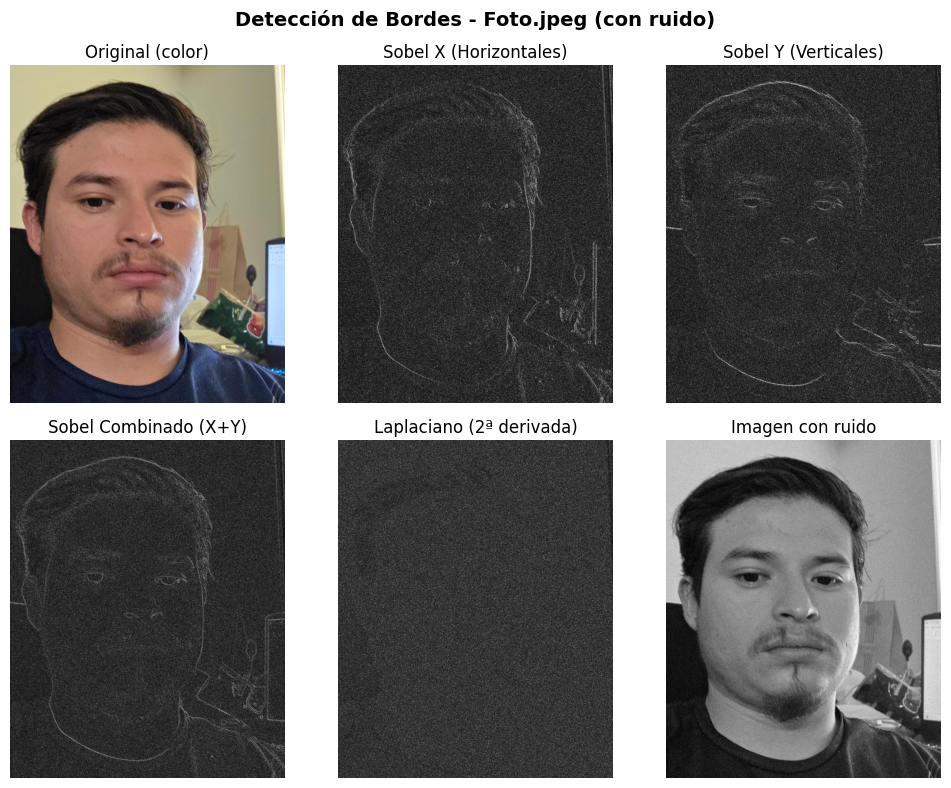

Procesamiento completado: Foto.jpeg (con ruido)


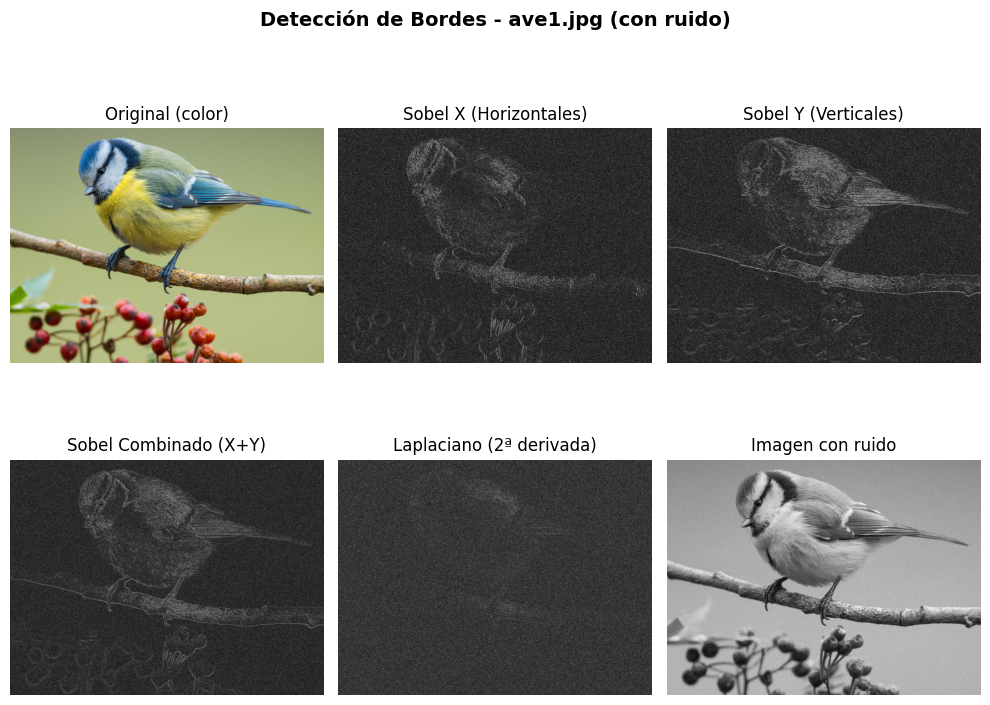

Procesamiento completado: ave1.jpg (con ruido)


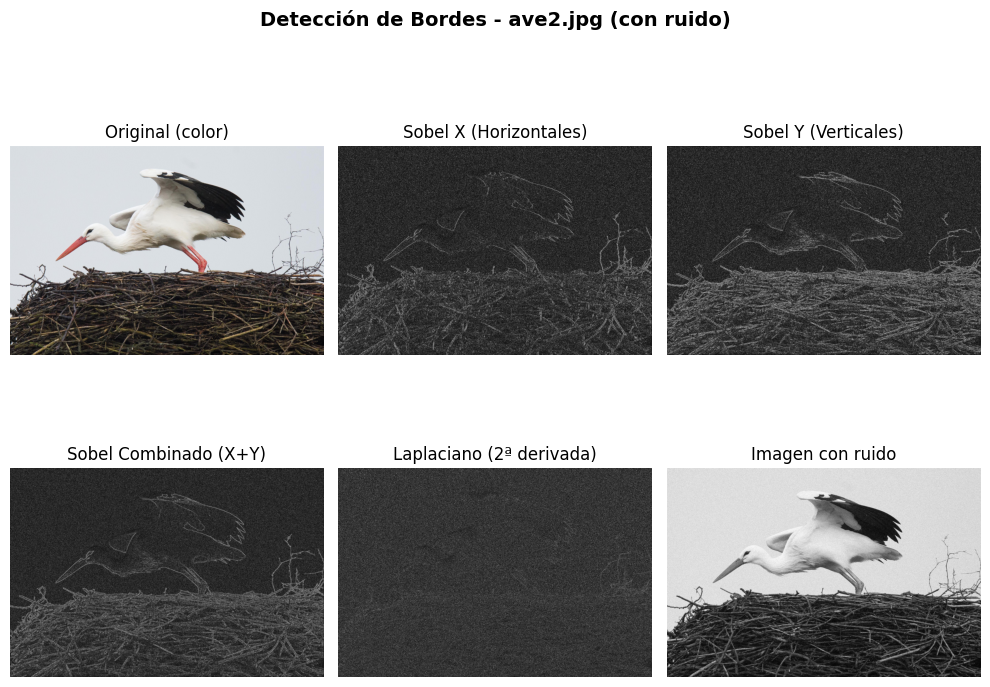

Procesamiento completado: ave2.jpg (con ruido)


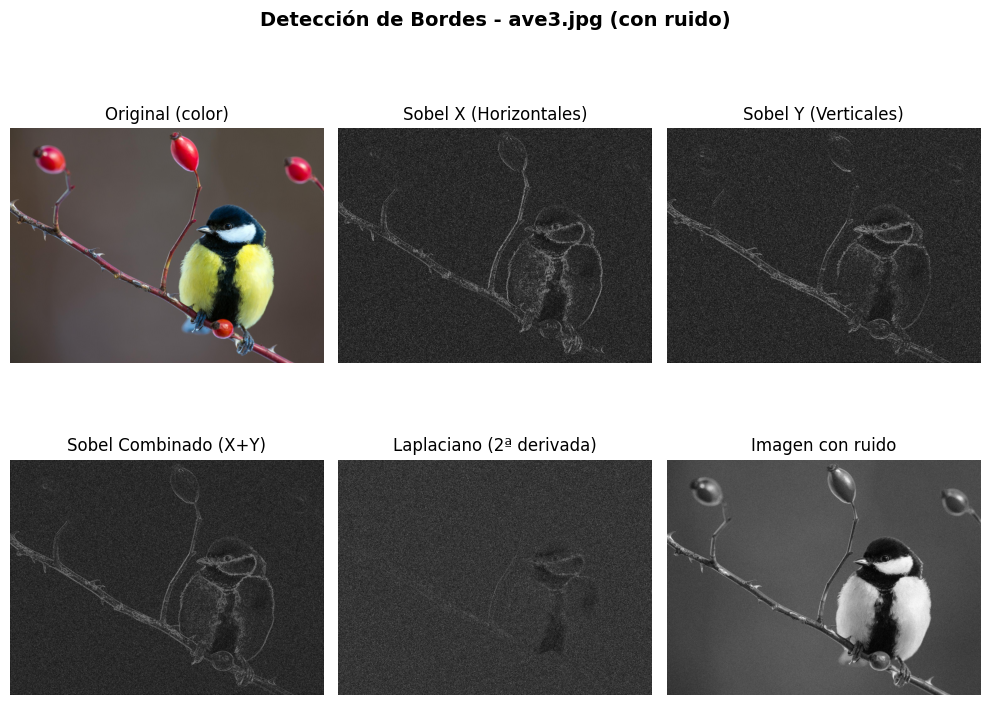

Procesamiento completado: ave3.jpg (con ruido)

 Todas las imágenes con ruido fueron procesadas correctamente.


In [14]:
print("\n Procesamiento CON ruido (para análisis de sensibilidad):")
for img in imagenes:
    procesar_imagen(img, aplicar_ruido=True)

print("\n Todas las imágenes con ruido fueron procesadas correctamente.")
